## Checking errors between GPU and CPU computation

In [1]:
# Importing crap
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('../..')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.patches as patches

import IRSMicroLensing.IRSFunctions as IRSF
import IRSMicroLensing.IRSCaustics2 as IRSC

import VBMicrolensing
import MulensModel as mm
import numexpr

import csv

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['figure.titlesize'] = 20
plt.rcParams['figure.titleweight'] = 'bold'
plt.rcParams['figure.figsize'] = (10, 8)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['figure.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['mathtext.fontset'] = 'cm'

In [2]:
VBM = VBMicrolensing.VBMicrolensing() # Instance to VBMicroLensing

class _MyBinaryLens(mm.BinaryLensPointSourceWM95Magnification):
    """Custom BinaryLens class potentially for modifications or extensions."""
    def __init__(self, q, s):
        # Initialize the parent MulensModel.BinaryLens
        self.s = s

        parameters = {'q': q, 's': s, 't_0': 0, 't_E': 1, 'u_0': 0.006, 'alpha': 0}
        model_params = mm.ModelParameters(parameters=parameters)

        traj = mm.Trajectory(times=0, parameters=model_params)

        super().__init__(trajectory=traj)

    def get_n_images(self, x, y):
        """
        Calculates the positions of images for a source at position (x, y).
        Relies on the _verify_polynomial_roots method from the parent class.
        """
        # The length of the list of roots corresponds to the number of images
        magnification = self._get_1_magnification(x, y, separation=self.s)

        # Getting image positions with the origin at the planet (0, 0)
        results = np.array(self._verify_polynomial_roots())

        # Shifting image positions to have origin at star
        for i in range(len(results)):
            results[i] += self.s + 0.0j

        return magnification, results

def _separate_circles(points, q, s):
    """
    Separate points into three circles.
    
    Parameters
    ----------
    points : Numpy NDArray
        Array of shape (N, 2) with all points
    q : float
        Planet to star mass ratio
    s : float
        x-coordinate of the off-center circle centroid (y = 0)
    
    Returns
    -------
    off_center : Numpy NDArray
        Points belonging to the off-center circle
    small_origin : Numpy NDArray
        Points belonging to the smaller origin-centered circle (avg radius < 1)
    large_origin : Numpy NDArray
        Points belonging to the larger origin-centered circle (avg radius > 1)
    """
    # Off-center circle parameters
    off_center = np.array([s, 0])
    off_radius = np.sqrt(q)

    # Distance of each point to off-center centroid
    d_off = np.linalg.norm(points - off_center, axis=1)

    # Assign off-center points if their radius is close to expected
    mask_off = np.abs(d_off - off_radius) < off_radius
    off_circle = points[mask_off]

    # Remaining points are origin-centered
    origin_points = points[~mask_off]

    # Compute radii of all origin-centered points
    r_origin = np.linalg.norm(origin_points, axis=1)

    # Split into two groups: below 1 and above 1
    small_mask = r_origin < 1
    small_origin = origin_points[small_mask]
    large_origin = origin_points[~small_mask]

    # (Optional) sanity check: swap if mislabeled
    if np.mean(np.linalg.norm(small_origin, axis=1)) > np.mean(np.linalg.norm(large_origin, axis=1)):
        small_origin, large_origin = large_origin, small_origin

    return off_circle, small_origin, large_origin

def _image_calculator(u, q, s):
    '''
    Calculates the major and minor radii for an annulus for a given source ring of radius u and binary lens configuration.

    Parameters
    ----------
    u : float
        Radius of source ring in units of Einstein radius
    q : float
        Planet to star mass ratio
    s : float
        Distance between star and planet in units of Einstein radius
    
    Returns
    -------
    y_plus : float
        Major image radius in units of Einstein radius
    y_minus : float
        Minor image radius in units of Einstein radius
    min_mag : float
        Minimum magnification in the source ring
    '''
    # Defining center of mass
    center_of_mass = np.array([q*s / (1 + q), 0])

    # Defining ring slightly larger than magnification map extent
    thetas = np.linspace(0, 2*np.pi, 1000, endpoint=False)
    xs = u * np.cos(thetas)
    ys = u * np.sin(thetas)

    # Initializing MulensModel binary lens
    model = _MyBinaryLens(q, s)

    # Defining lists to hold all image positions and magnifications
    all_points = []
    ring_magnifications = []

    # Iterating through all source positions in ring
    for x, y in zip(xs, ys):
        # Calculating corresponding magnifications and image positions
        magnification, image_positions = model.get_n_images(x - center_of_mass[0], y - center_of_mass[1])

        # Storing all image positions
        for image_position in image_positions:
            all_points.append([image_position.real, image_position.imag])

        # Storing magnifications
        ring_magnifications.append(magnification)

    # Converting to Numpy arrays
    all_points = np.array(all_points)
    ring_magnifications = np.array(ring_magnifications)

    # Separating points into three critical curves: off-centered circle around planet, smaller origin-centered circle, larger origin-centered circle
    offset_circle, small_circle, large_circle = _separate_circles(all_points, q, s)

    # Calculating polar coordinates of the points of each circle
    small_rs = np.sqrt(small_circle[:, 0]**2 + small_circle[:, 1]**2)
    small_thetas = np.arctan2(small_circle[:, 1], small_circle[:, 0]) * 180 / np.pi

    big_rs = np.sqrt(large_circle[:, 0]**2 + large_circle[:, 1]**2)
    big_thetas = np.arctan2(large_circle[:, 1], large_circle[:, 0]) * 180 / np.pi

    # Averaging radii of each circle to get y+ and y-
    # y+ is the average radius of the larger origin-centered circle
    # y- is the average radius of the smaller origin-centered circle
    y_plus = np.mean(big_rs)
    y_minus = np.mean(small_rs)

    return y_plus, y_minus, np.min(ring_magnifications)

def _ang_width_calculator(lens_att: list | np.ndarray, pixels_in_small_source: int = 10, cm_offset: str | tuple | list = [0, 0], cm_translation: tuple | list = [0, 0]):
    '''
    Calculates the angular width of the magnification map using Equations 8-10 in https://arxiv.org/pdf/astro-ph/0505363.

    Parameters
    ----------
    lens_att : list
        Passed through via passed_params dict
    pixels_in_small_source : int, optional
        Number of pixels to cover the diameter of the smallest source. Default is 10
    cm_offset : str or tuple or list, optional
        Center of mass offset to be added to caustic positions. If 'auto', then the center of mass of each star-planet combination is used. Default is [0, 0]
    cm_translation : tuple or list, optional
        Center of mass translation to be applied to caustic positions. Default is [0, 0]

    Returns
    -------
    pixels : int
        Number of pixels along one side of the square magnification map
    ang_width : float
        Angular width of ray sampling region
    (qs, ss) : tuple of lists
        Mass ratios and separations of each star-planet combination
    points : Lx4x2 NDArray
        Locations of caustic cusps in the inertial frame
    (max_source_radius, min_source_radius) : tuple of floats
        Maximum and minimum source radii to be used for the simulation
    '''
    lens_att = np.array(lens_att)
    
    # Number of lens objects
    L = np.shape(lens_att)[0]

    # If radii
    if np.shape(lens_att)[1] == 4:
        mass_ind = 3
    else:
        mass_ind = 2

    # Initializing maximum distance from origin list
    max_dist_rot = []
    max_dist = []
    points = np.zeros(shape=(L-1, 4, 2))

    caustic_sizes = []

    qs = []
    ss = []

    # Calculating the center of masses of each individual star-planet combination
    lens_CMs_rot = np.zeros(shape=(L-1, 2))
    
    if L == 1:
        raise ValueError('Only one lens object detected. Cannot calculate angular width for single lens using this function.')

    else:
        for i, lens in enumerate(lens_att[1:]):
            two_lenses = np.array([lens_att[0], lens])

            # Finding which index the bigger mass was passed in (primary lens)
            big_mass = np.where(two_lenses[:, mass_ind] == np.max(two_lenses[:, mass_ind]))[0][0]

            # Secondary lens
            small_mass = int(not big_mass)

            # Defining unit source vector
            uhat = [1, 0]

            # Defining unit binary axis vector (from primary to secondary lens)
            v = [two_lenses[small_mass, 0] - two_lenses[big_mass, 0], two_lenses[small_mass, 1] - two_lenses[big_mass, 1]]
            vhat = v / np.linalg.norm(v)

            # Finding counterclockwise angle between binary axis and source trajectory (alpha)
            if vhat[0] > 0 and vhat[1] > 0:
                alpha = np.arctan(vhat[1]/vhat[0])
            elif vhat[0] < 0 and vhat[1] > 0:
                alpha = np.pi + np.arctan(vhat[1]/vhat[0])
            elif vhat[0] < 0 and vhat[1] < 0:
                alpha = np.pi + np.arctan(vhat[1]/vhat[0])
            elif vhat[0] > 0 and vhat[1] < 0:
                alpha = np.arctan(vhat[1]/vhat[0])
            elif vhat[0] > 0 and vhat[1] == 0:
                alpha = 0
            elif vhat[0] == 0 and vhat[1] > 0:
                alpha = np.pi/2
            elif vhat[0] < 0 and vhat[1] == 0:
                alpha = np.pi
            elif vhat[0] == 0 and vhat[1] < 0:
                alpha = -np.pi/2

            # Calculating distance between lenses (s)
            s = np.linalg.norm(v)
            ss.append(s)

            # Calculating mass ratio between lenses (q)
            q = two_lenses[small_mass, mass_ind] / two_lenses[big_mass, mass_ind]
            qs.append(q)

            # Calculating center of mass in binary axis
            lens_CMs_rot[i, 0] = q*s / (1 + q)

            # Creating rotation matrix
            cos, sin = np.cos(alpha), np.sin(alpha)
            Rot = np.array([[cos, -sin], [sin, cos]])

            # Finding cos(phi_c) - Equation 10
            cos_phi_c = 3/4 * (s + s**-1) * (1 - np.sqrt(1 - 32/9*(s + s**-1)**-2))

            # Finding phi_c through arccos
            phi_c = np.arccos(cos_phi_c)

            if cm_offset == 'auto':
                lens_CM = lens_CMs_rot[i]

            # Finding positive x and negative x positions - Equation 8
            x_pos_rot = q / ((1 + s)*(1 + s**-1)) - lens_CMs_rot[i, 0]
            x_neg_rot = -q / ((1 - s)*(1 - s**-1)) - lens_CMs_rot[i, 0]

            # Finding positive y and negative y positions - Equation 9
            y_pos_rot = (2*q * np.abs(np.sin(phi_c)**3)) / (s + s**-1 - 2*cos_phi_c)**2 - lens_CMs_rot[i, 1]
            y_neg_rot = -(2*q * np.abs(np.sin(phi_c)**3)) / (s + s**-1 - 2*cos_phi_c)**2 - lens_CMs_rot[i, 1]

            # Storing the maximum distance from the origin of the caustic
            max_dist_rot.append(np.max(np.abs(np.array([x_pos_rot, x_neg_rot, y_pos_rot, y_neg_rot]))))

            # Rotating bounding points back from binary axis to inertial axis
            x_pos = np.dot(Rot, np.array([x_pos_rot, 0])) + lens_CM - cm_translation
            x_neg = np.dot(Rot, np.array([x_neg_rot, 0])) + lens_CM - cm_translation

            y_pos = np.dot(Rot, np.array([0, y_pos_rot])) # + lens_CM - cm_translation
            y_neg = np.dot(Rot, np.array([0, y_neg_rot])) # + lens_CM - cm_translation

            # Finding maximum distance from the origin and storing it
            points[i, :, :] = np.array([x_pos, x_neg, y_pos, y_neg])
            max_dist.append(np.max(np.abs(points[i, :, :])))

            width = abs(x_pos_rot - x_neg_rot)
            height = abs(y_pos_rot - y_neg_rot)

            caustic_sizes.append(max(width, height))

    # Finding the maximum distance of a cusp from the origin among all caustics
    max_cusp_distance = np.max(max_dist)

    # Finding maximum caustic size
    max_caustic_size = np.max(caustic_sizes)

    # Finding maximum source radius
    max_source_radius = (10 * max_caustic_size) / 2
    min_source_radius = max_source_radius / 100

    # Adding source diameter as padding
    ang_width_source = 2 * (max_cusp_distance + 2.1*max_source_radius)

    # Angular width regardless of source size
    ang_width_nosource = 4 * max_cusp_distance

    # Choose largest width:
    ang_width = max(ang_width_source, ang_width_nosource)

    # Making map twice as wide as the minimum required
    ang_width *= 2

    # Determining the number of pixels such that the source radius is covered by at least a certain number of pixels
    ang_res = min_source_radius*2 / pixels_in_small_source
    pixels = int(ang_width / ang_res) + 1

    return pixels, ang_width, (qs, ss), points, (max_source_radius, min_source_radius)

def _annulus_bounds_calculator(ang_width: float, qs: list, ss: list, annulus_center: list | np.ndarray = None):
    '''
    Calculates the annulus bounds and minimum magnification for a given angular width and lens configuration.

    Parameters
    ----------
    ang_width : float
        Angular width of ray sampling region
    qs : list
        Mass ratios of each star-planet combination. For a single lens, pass None
    ss : list
        Separations of each star-planet combination. For a single lens, pass None
    annulus_center : list, optional
        Center of annulus. Default is None, which means no offset is applied

    Returns
    -------
    (y_plus, y_minus) : tuple
        Major and minor image positions
    min_mag : float
        Minimum magnification in the source ring
    '''
    # Number of lens objects
    if qs is None or ss is None:
        L = 1
    else:
        L = len(qs) + 1

    # Finding the maximum distance from the origin of magnification map
    u = 1.05 * ang_width / np.sqrt(2)
    
    if annulus_center is not None:
        annulus_center = -np.array(annulus_center)
        
        if annulus_center[0] > 0 and annulus_center[1] > 0:
            angle = np.arctan(annulus_center[1]/annulus_center[0])
        elif annulus_center[0] < 0 and annulus_center[1] > 0:
            angle = np.pi + np.arctan(annulus_center[1]/annulus_center[0])
        elif annulus_center[0] < 0 and annulus_center[1] < 0:
            angle = np.pi + np.arctan(annulus_center[1]/annulus_center[0])
        elif annulus_center[0] > 0 and annulus_center[1] < 0:
            angle = np.arctan(annulus_center[1]/annulus_center[0])
        elif annulus_center[0] > 0 and annulus_center[1] == 0:
            angle = 0
        elif annulus_center[0] == 0 and annulus_center[1] > 0:
            angle = np.pi/2
        elif annulus_center[0] < 0 and annulus_center[1] == 0:
            angle = np.pi
        elif annulus_center[0] == 0 and annulus_center[1] < 0:
            angle = -np.pi/2

        u = np.sqrt(u**2 + np.linalg.norm(annulus_center)**2 - 2*u*np.linalg.norm(annulus_center)*np.cos(angle - np.pi/4))
    
    # Finding major and minor image positions (y+ > 0 and y- < 0)
    if L == 1:
        # For a single lens
        y_plus = np.abs(0.5 * (u + np.sqrt(u**2 + 4)))
        y_minus = np.abs(0.5 * (u - np.sqrt(u**2 + 4)))

        # Calculate analytic magnification for a single lens
        min_mag = (u**2 + 2) / (u * np.sqrt(u**2 + 4))

    else:
        # For multiple lenses, find the annulus bounds for each star-planet combination and take the bounds that give the largest annulus
        y_pluses = []
        y_minuses = []
        min_mags = []

        for q, s in zip(qs, ss):
            y_plus, y_minus, min_mag = _image_calculator(u, q, s)
            y_pluses.append(y_plus)
            y_minuses.append(y_minus)
            min_mags.append(min_mag)

        y_plus = np.max(y_pluses)
        y_minus = np.min(y_minuses)

        # Taking the minimum magnification among all star-planet combinations
        min_mag = np.min(min_mags)

    return (y_plus, y_minus), min_mag

def _num_ray_calculator(pixels: int, ang_width: float, y_plus: float, y_minus: float, min_mag: float, delta: float = 0.01, r_theta_ratio: int | float = 4):
    '''
    Calculates the number of rays to shoot in r and theta directions to achieve the desired error in the image plane.

    Parameters
    ----------
    pixels : int
        Number of pixels along one side of the square magnification map
    ang_width : float
        Angular width of ray sampling region
    y_plus : float
        Major image position
    y_minus : float
        Minor image position
    min_mag : float
        Minimum magnification in the source ring
    delta : float, optional
        Desired error in the source plane in units of Einstein radius. Default is 0.01
    r_theta_ratio : int or float, optional
        Ratio of number of rays in r to number of rays in theta. Default is 4

    Returns
    -------
    num_r : int
        Number of rays in radial direction
    num_theta : int
        Number of rays in angular direction
    '''
    # Width of pixel
    dx = ang_width / (pixels - 1)

    # Area of annulus
    a_ann = (np.pi * (y_plus**2 - y_minus**2))

    # Ray density in annulus
    n_image = 1 / (min_mag * dx**2 * delta**2)

    # Total number of rays
    N_rays = n_image * a_ann

    # Number of rays in theta
    num_theta = int(np.ceil(np.sqrt(N_rays / r_theta_ratio)))

    # Number of rays in r
    num_r = int(np.ceil(r_theta_ratio * num_theta))

    return num_r, num_theta

In [3]:
q1 = 1e-3
s1 = 0.2
q2 = 3e-4
s2 = 0.6
alpha = 45

triple_lens_att_1 = np.array([
    [0, 0, 1], # Star at origin with mass 1
    [s1, 0, q1], # Big planet
    [s2*np.cos(np.radians(alpha)), s2*np.sin(np.radians(alpha)), q2] # Small planet at angle alpha
])

parameters = triple_lens_att_1.flatten().tolist()
VBM.SetLensGeometry(parameters)
caustics = VBM.Multicaustics() # Get caustics for the triple lens configuration
caustics = np.array(caustics, dtype=object)

caustic_big = VBM.Caustics(s1, q1) # Get caustics for the big planet alone
caustic_big = np.array(caustic_big, dtype=object)
caustic_small = VBM.Caustics(s2, q2) # Get caustics for the small planet alone
caustic_small = np.array(caustic_small, dtype=object)

center_of_mass_big = np.array([q1*s1 / (1 + q1), 0])
center_of_mass_small = np.array([q2*s2 / (1 + q2)*np.cos(np.radians(alpha)), q2*s2 / (1 + q2)*np.sin(np.radians(alpha))])

center_of_mass = np.average(triple_lens_att_1[:, :2], axis=0, weights=triple_lens_att_1[:, 2])
center_of_magnification = np.array([q2 / ((1 + q2) * (s1 + 1/s1)), 0])

triple_lens_att_1[:, :2] -= center_of_magnification

pixels, ang_width, (qs_list_1, ss_list_1), cusp_points, (max_source_radius, min_source_radius) = _ang_width_calculator(triple_lens_att_1, cm_offset='auto', cm_translation=[0, 0], pixels_in_small_source=10)

pixels = 1000
ang_width = 0.2

(y_plus, y_minus), min_mag = _annulus_bounds_calculator(ang_width, qs=qs_list_1, ss=ss_list_1)
num_r, num_theta = _num_ray_calculator(pixels, ang_width, y_plus, y_minus, min_mag, delta=0.02, r_theta_ratio=4)

print(f'Pixels: {pixels}')
print(f'Angular width: {ang_width}')
print(f'Minimum magnification: {min_mag}')
print(f'Annulus bounds: y+ = {y_plus}, y- = {y_minus}, thickness = {y_plus - y_minus}')
print(f'Average radius of annulus: {(y_plus + y_minus)/2}')
print(f'Number of rays: num_r = {num_r}, num_theta = {num_theta}')
print(f'Total number of rays: {(num_r * num_theta):.3e}')
print(f'Maximum source radius: {max_source_radius}')
print(f'Minimum source radius: {min_source_radius}')

triple_lens_parameters_1 = {
    'lens_att': triple_lens_att_1.tolist(),
    'pixels': pixels,
    'ang_width': ang_width,
    'num_r': num_r,
    'num_theta': num_theta,
    'y_plus': y_plus,
    'y_minus': y_minus,
    'thickness': y_plus - y_minus
}

Pixels: 1000
Angular width: 0.2
Minimum magnification: 6.754609827054506
Annulus bounds: y+ = 1.0769985822006392, y- = 0.9285063760849294, thickness = 0.1484922061157098
Average radius of annulus: 1.0027524791427842
Number of rays: num_r = 185900, num_theta = 46475
Total number of rays: 8.640e+09
Maximum source radius: 0.005273437499999999
Minimum source radius: 5.2734374999999986e-05


In [46]:
triple_cpu = IRSC.caustic_reader('./Data Files/triple_sim_cpu.pkl')
triple_gpu = IRSC.caustic_reader('./Data Files/triple_sim_gpu2.pkl')

cpu_magnifications = triple_cpu.magnifications
gpu_magnifications = triple_gpu.magnifications

# Verifying variables in the two simulations are the same
print(triple_cpu.ang_width == triple_gpu.ang_width)
print(triple_cpu.ang_res == triple_gpu.ang_res)
print(np.all(triple_cpu.lens_att == triple_gpu.lens_att))
print(triple_cpu.pixels == triple_gpu.pixels)
print(triple_cpu.num_r == triple_gpu.num_r)
print(triple_cpu.num_theta == triple_gpu.num_theta)
print(triple_cpu.y_plus == triple_gpu.y_plus)
print(triple_cpu.y_minus == triple_gpu.y_minus)
print(triple_cpu.thickness == triple_gpu.thickness)
print(np.all(cpu_magnifications == gpu_magnifications))

True
True
True
True
True
True
True
True
True
False


Determining differences between cpu and gpu calculations

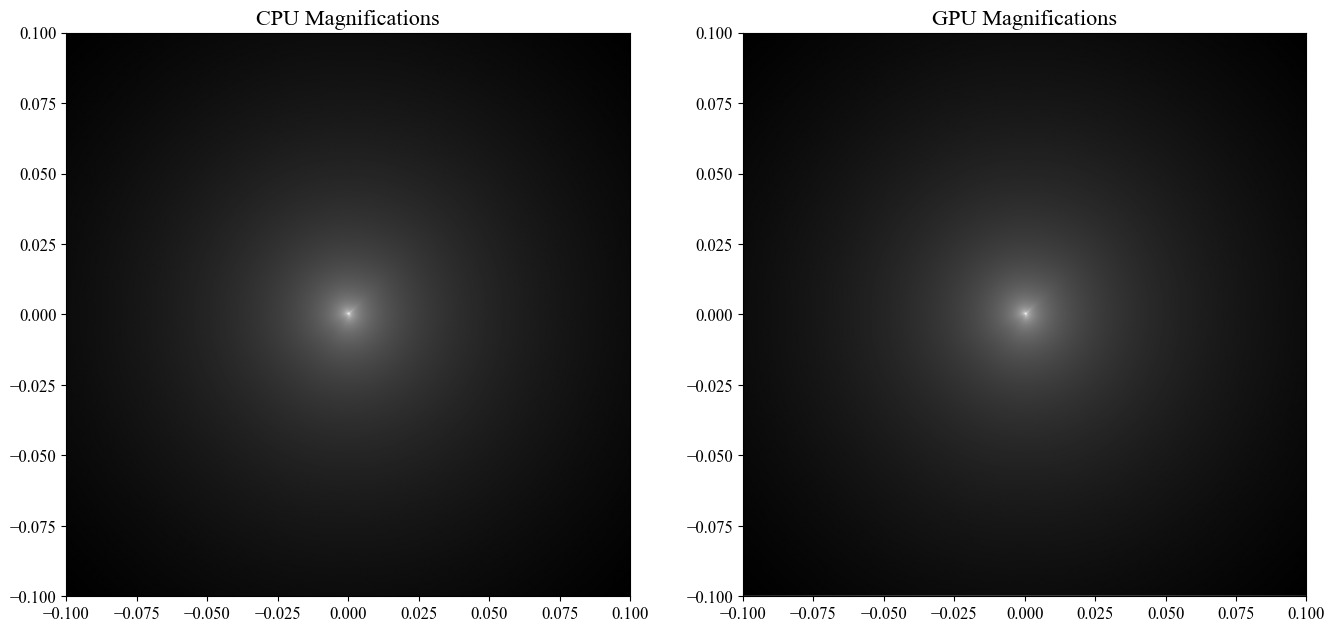

In [47]:
fig = plt.figure(figsize=(16, 8))
ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2)

max_mag = np.max(np.log10(cpu_magnifications))
min_mag = np.min(np.log10(cpu_magnifications))

ax1.imshow(np.log10(cpu_magnifications), cmap='gray', extent=[-triple_cpu.ang_width/2 - triple_cpu.ang_res/2, triple_cpu.ang_width/2 + triple_cpu.ang_res/2, -triple_cpu.ang_width/2 - triple_cpu.ang_res/2, triple_cpu.ang_width/2 + triple_cpu.ang_res/2], vmin=min_mag, vmax=max_mag)
ax2.imshow(np.log10(gpu_magnifications), cmap='gray', extent=[-triple_gpu.ang_width/2 - triple_gpu.ang_res/2, triple_gpu.ang_width/2 + triple_gpu.ang_res/2, -triple_gpu.ang_width/2 - triple_gpu.ang_res/2, triple_gpu.ang_width/2 + triple_gpu.ang_res/2], vmin=min_mag, vmax=max_mag)

ax1.set_title('CPU Magnifications')
ax2.set_title('GPU Magnifications')

view = triple_cpu.ang_width/2
ax1.set_xlim(-view, view)
ax1.set_ylim(-view, view)
ax2.set_xlim(-view, view)
ax2.set_ylim(-view, view)

plt.show()

Pixels where CPU == GPU exactly: 996004 / 1000000
Pixels where CPU == 0:           0
Pixels where GPU == 0:           0

Relative deviation (ignoring zero-CPU pixels):
  max  = 1461.781525  (146178.1525%)
  mean = 0.629725  (62.9725%)
  median = 0.000000

Absolute difference:
  max  = 10324.642925
  mean = 5.713978

Max relative deviation at pixel (np.int64(999), np.int64(0))
  CPU value = 7.063055e+00
  GPU value = 1.033171e+04
  abs diff  = 1.032464e+04

Max absolute deviation at pixel (np.int64(999), np.int64(0))
  CPU value = 7.063055e+00
  GPU value = 1.033171e+04
  abs diff  = 1.032464e+04


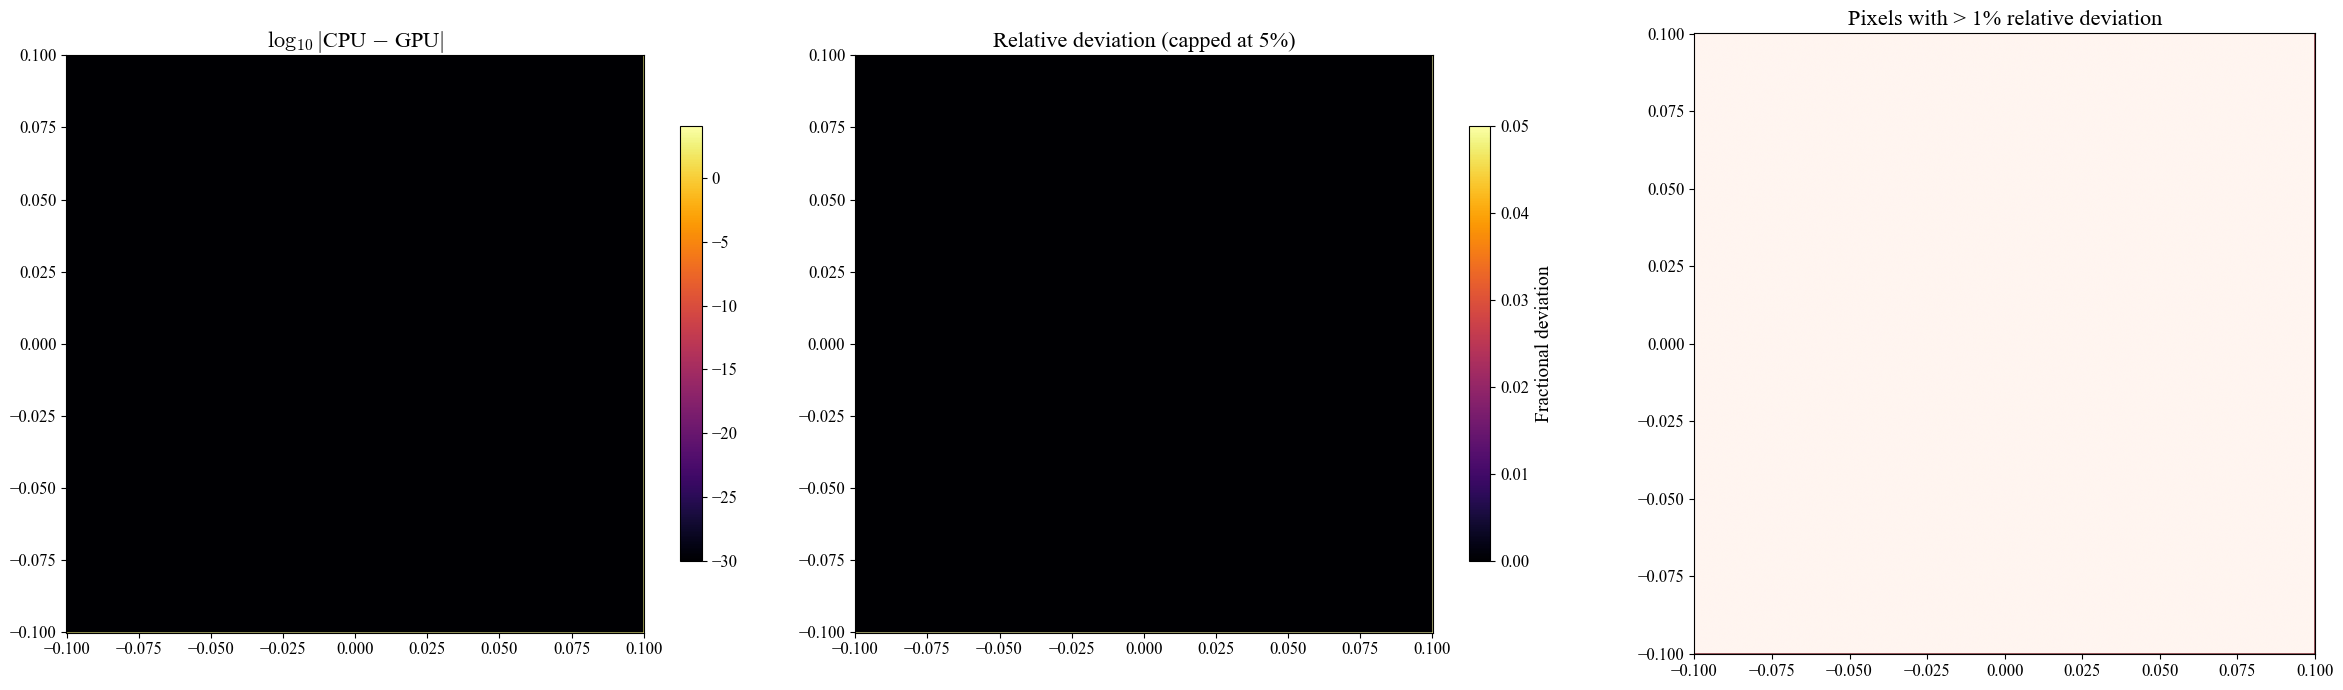

In [48]:
extent = [
    -triple_cpu.ang_width/2 - triple_cpu.ang_res/2,
     triple_cpu.ang_width/2 + triple_cpu.ang_res/2,
    -triple_cpu.ang_width/2 - triple_cpu.ang_res/2,
     triple_cpu.ang_width/2 + triple_cpu.ang_res/2,
]

abs_diff = np.abs(cpu_magnifications - gpu_magnifications)

# Relative deviation, guarded against division by zero / near-zero
safe_cpu = np.where(cpu_magnifications > 0, cpu_magnifications, np.nan)
rel_deviation = abs_diff / safe_cpu

# --- Diagnostics ---
print(f"Pixels where CPU == GPU exactly: {np.sum(cpu_magnifications == gpu_magnifications)} / {cpu_magnifications.size}")
print(f"Pixels where CPU == 0:           {np.sum(cpu_magnifications == 0)}")
print(f"Pixels where GPU == 0:           {np.sum(gpu_magnifications == 0)}")
print()

# Stats ignoring NaN (zero-CPU pixels)
print(f"Relative deviation (ignoring zero-CPU pixels):")
print(f"  max  = {np.nanmax(rel_deviation):.6f}  ({np.nanmax(rel_deviation)*100:.4f}%)")
print(f"  mean = {np.nanmean(rel_deviation):.6f}  ({np.nanmean(rel_deviation)*100:.4f}%)")
print(f"  median = {np.nanmedian(rel_deviation):.6f}")
print()

print(f"Absolute difference:")
print(f"  max  = {np.max(abs_diff):.6f}")
print(f"  mean = {np.mean(abs_diff):.6f}")
print()

# Location of the maximum relative deviation
max_idx = np.unravel_index(np.nanargmax(rel_deviation), rel_deviation.shape)
print(f"Max relative deviation at pixel {max_idx}")
print(f"  CPU value = {cpu_magnifications[max_idx]:.6e}")
print(f"  GPU value = {gpu_magnifications[max_idx]:.6e}")
print(f"  abs diff  = {abs_diff[max_idx]:.6e}")
print()

# Location of the maximum absolute deviation
max_abs_idx = np.unravel_index(np.argmax(abs_diff), abs_diff.shape)
print(f"Max absolute deviation at pixel {max_abs_idx}")
print(f"  CPU value = {cpu_magnifications[max_abs_idx]:.6e}")
print(f"  GPU value = {gpu_magnifications[max_abs_idx]:.6e}")
print(f"  abs diff  = {abs_diff[max_abs_idx]:.6e}")

# --- Plots ---
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

# 1) Absolute difference (log scale)
log_abs = np.log10(abs_diff + 1e-30)
im0 = axes[0].imshow(log_abs, cmap='inferno', extent=extent)
fig.colorbar(im0, ax=axes[0], shrink=0.7)
axes[0].set_title(r'$\log_{10}|$CPU $-$ GPU$|$')

# 2) Relative deviation with capped color scale
im1 = axes[1].imshow(rel_deviation, cmap='inferno', extent=extent, vmin=0, vmax=0.05)
fig.colorbar(im1, ax=axes[1], shrink=0.7, label='Fractional deviation')
axes[1].set_title('Relative deviation (capped at 5%)')

# 3) Highlight pixels above 1% relative deviation
highlight = np.zeros_like(rel_deviation)
highlight[rel_deviation > 0.01] = 1.0
im2 = axes[2].imshow(highlight, cmap='Reds', extent=extent, vmin=0, vmax=1)
axes[2].set_title('Pixels with > 1% relative deviation')

plt.tight_layout()
plt.show()

Map size: 1000x1000 = 1000000 pixels
Edge pixels (outermost 1 rows/cols): 3996
Interior pixels: 996004

=== Signed difference (GPU - CPU) ===
  Edge pixels:
    mean  = 1.429924e+03
    max   = 1.032464e+04
    sum   = 5.713978e+06
  Interior pixels:
    mean  = 0.000000e+00
    max   = 0.000000e+00
    sum   = 0.000000e+00

=== Corner pixel values (2x2) ===
  Top-left:
    CPU = [[7.08741943 7.10366256]
 [7.10636975 7.095541  ]]
    GPU = [[9.54573066e+03 3.61767010e+02]
 [3.63050218e+02 7.09554100e+00]]
    diff = [[9538.64323694  354.66334791]
 [ 355.94384806    0.        ]]

  Top-right:
    CPU = [[7.12532007 7.12532007]
 [7.14697758 7.12532007]]
    GPU = [[3.37304855e+02 8.17139935e+03]
 [7.14697758e+00 3.36511649e+02]]
    diff = [[ 330.17953533 8164.27403441]
 [   0.          329.3863291 ]]

  Bottom-left:
    CPU = [[7.06034755 7.08471224]
 [7.06305473 7.03598285]]
    GPU = [[3.75535771e+02 7.08471224e+00]
 [1.03317060e+04 3.74593669e+02]]
    diff = [[  368.47542351     0. 

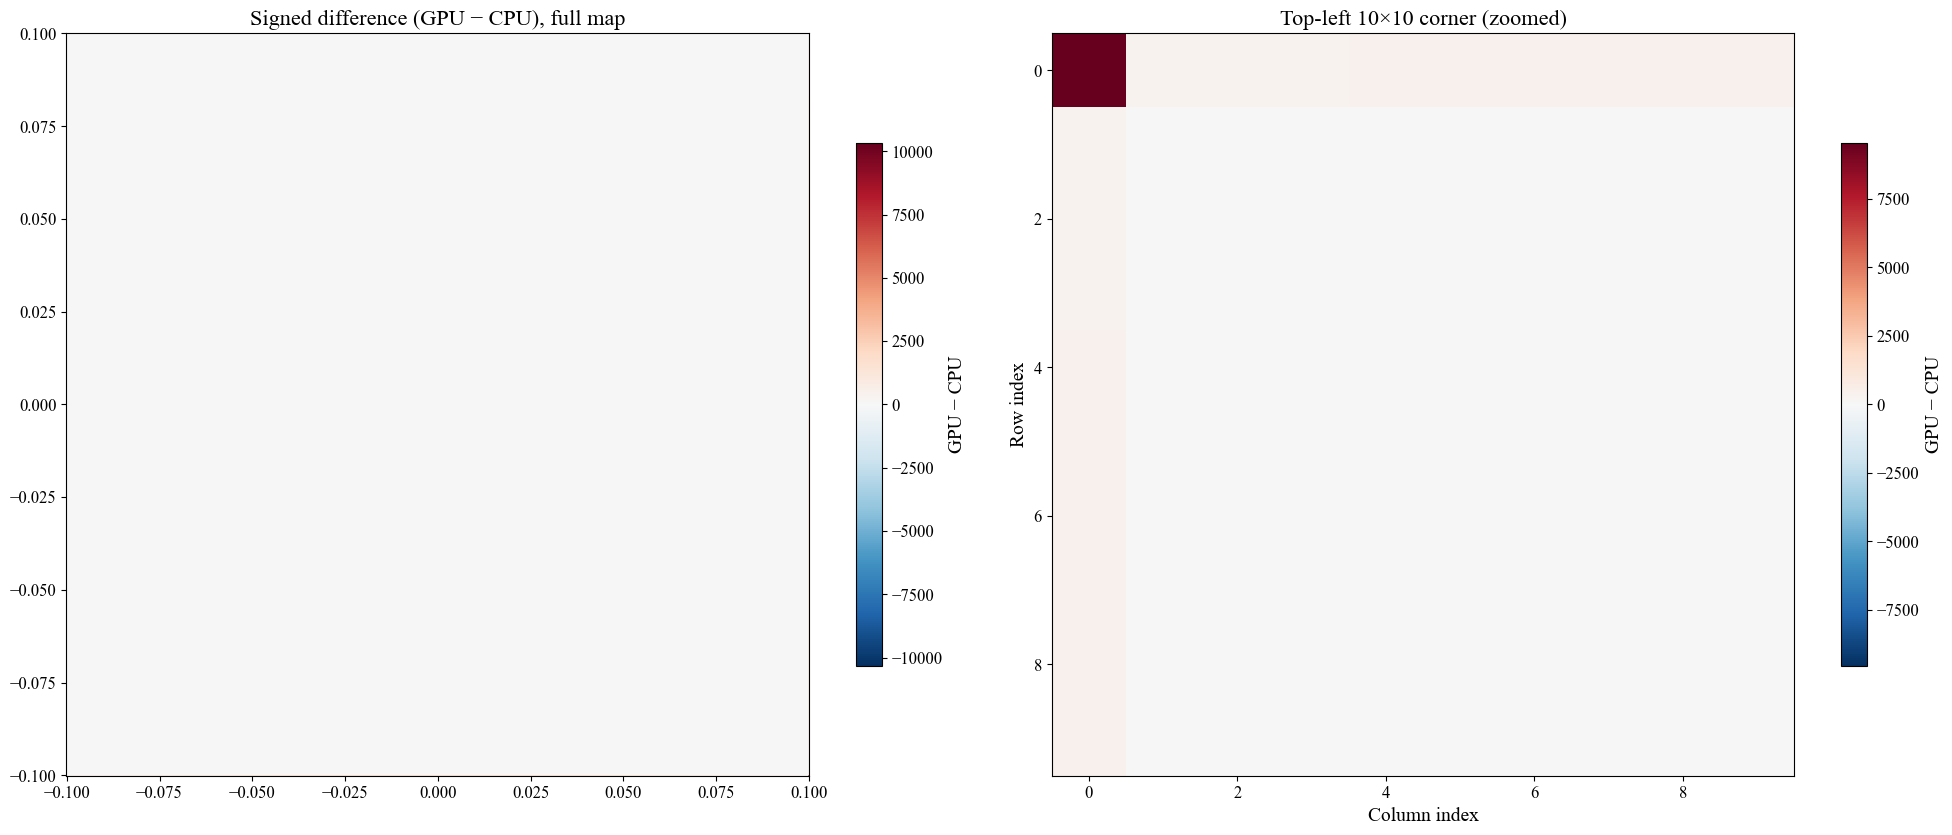


>>> DIAGNOSIS: The GPU bin_rays_gpu() used cp.clip() to push out-of-bounds
    rays into edge bins (pixels 0 and pixels-1). The CPU fast_binning()
    discards them instead. This causes the GPU map to have excess counts
    at the edges/corners. Fix: discard out-of-bounds rays in bin_rays_gpu().


In [58]:
# ── Edge/Corner contamination analysis ──
# The GPU's bin_rays_gpu clips out-of-bounds rays to edge bins (0 and pixels-1),
# while the CPU's fast_binning discards them entirely. This causes excess counts
# in the edge rows/columns of the GPU map, especially the corners.

pixels = cpu_magnifications.shape[0]
diff = gpu_magnifications - cpu_magnifications  # signed: positive = GPU has more

# Define "edge" as the outermost k rows/columns
k = 1

# Build edge mask (True for pixels in the outermost k rows/columns)
edge_mask = np.zeros_like(cpu_magnifications, dtype=bool)
edge_mask[:k, :] = True      # top k rows
edge_mask[-k:, :] = True     # bottom k rows
edge_mask[:, :k] = True      # left k columns
edge_mask[:, -k:] = True     # right k columns

interior_mask = ~edge_mask

print(f"Map size: {pixels}x{pixels} = {pixels**2} pixels")
print(f"Edge pixels (outermost {k} rows/cols): {np.sum(edge_mask)}")
print(f"Interior pixels: {np.sum(interior_mask)}")
print()

# Where does the signed difference (GPU - CPU) land?
print("=== Signed difference (GPU - CPU) ===")
print(f"  Edge pixels:")
print(f"    mean  = {np.mean(diff[edge_mask]):.6e}")
print(f"    max   = {np.max(diff[edge_mask]):.6e}")
print(f"    sum   = {np.sum(diff[edge_mask]):.6e}")
print(f"  Interior pixels:")
print(f"    mean  = {np.mean(diff[interior_mask]):.6e}")
print(f"    max   = {np.max(diff[interior_mask]):.6e}")
print(f"    sum   = {np.sum(diff[interior_mask]):.6e}")
print()

# Corner analysis (2x2 corners)
corners = {
    "Top-left":     (slice(0, 2), slice(0, 2)),
    "Top-right":    (slice(0, 2), slice(-2, None)),
    "Bottom-left":  (slice(-2, None), slice(0, 2)),
    "Bottom-right": (slice(-2, None), slice(-2, None)),
}

print("=== Corner pixel values (2x2) ===")
for name, (r, c) in corners.items():
    cpu_val = cpu_magnifications[r, c]
    gpu_val = gpu_magnifications[r, c]
    print(f"  {name}:")
    print(f"    CPU = {cpu_val}")
    print(f"    GPU = {gpu_val}")
    print(f"    diff = {gpu_val - cpu_val}")
    print()

# Are there pixels where CPU == 0 but GPU > 0? (rays that only GPU counts)
cpu_zero_gpu_nonzero = (cpu_magnifications == 0) & (gpu_magnifications > 0)
print(f"Pixels where CPU=0 but GPU>0: {np.sum(cpu_zero_gpu_nonzero)}")
print(f"  Of those, on edges: {np.sum(cpu_zero_gpu_nonzero & edge_mask)}")
print(f"  Of those, in interior: {np.sum(cpu_zero_gpu_nonzero & interior_mask)}")
print()

# --- Visualize: signed difference map (GPU - CPU) ---
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Full map
im0 = axes[0].imshow(diff, cmap='RdBu_r', extent=extent,
                      vmin=-np.max(np.abs(diff[edge_mask])),
                      vmax=np.max(np.abs(diff[edge_mask])))
fig.colorbar(im0, ax=axes[0], shrink=0.7, label='GPU − CPU')
axes[0].set_title('Signed difference (GPU − CPU), full map')

# Zoomed to corner to show contamination
corner_extent = 10  # pixels from edge to zoom into
im1 = axes[1].imshow(diff[:corner_extent, :corner_extent], cmap='RdBu_r',
                      vmin=-np.max(np.abs(diff[:corner_extent, :corner_extent])),
                      vmax=np.max(np.abs(diff[:corner_extent, :corner_extent])),
                      interpolation='nearest')
fig.colorbar(im1, ax=axes[1], shrink=0.7, label='GPU − CPU')
axes[1].set_title(f'Top-left {corner_extent}×{corner_extent} corner (zoomed)')
axes[1].set_xlabel('Column index')
axes[1].set_ylabel('Row index')

plt.tight_layout()
plt.show()

print("\n>>> DIAGNOSIS: The GPU bin_rays_gpu() used cp.clip() to push out-of-bounds")
print("    rays into edge bins (pixels 0 and pixels-1). The CPU fast_binning()")
print("    discards them instead. This causes the GPU map to have excess counts")
print("    at the edges/corners. Fix: discard out-of-bounds rays in bin_rays_gpu().")

In [54]:
# Checking corners of the maps
print(cpu_magnifications[999, 0])
print(gpu_magnifications[999, 0])

print(cpu_magnifications[0, 0])
print(gpu_magnifications[0, 0])

print(cpu_magnifications[0, 999])
print(gpu_magnifications[0, 999])

print(cpu_magnifications[999, 999])
print(gpu_magnifications[999, 999])

7.063054734756671
10331.705979517497
7.08741943104368
9545.730656371783
7.125320069712363
8171.399354475819
7.114491315807026
8703.575757965176


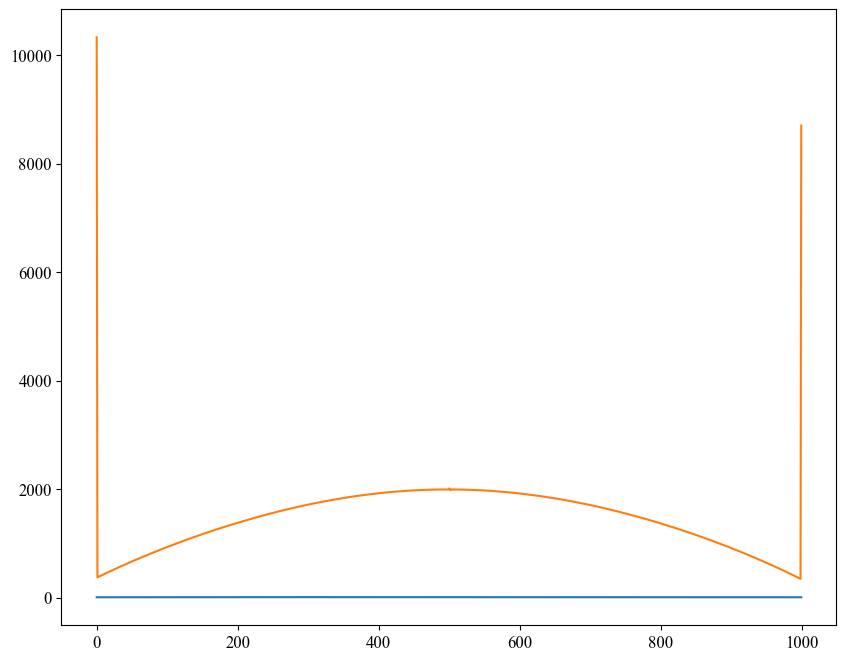

In [ ]:
# Taking cross sections of the maps
row = 999


